In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown, FloatSlider, SelectionSlider
import os
from tqdm import tqdm

---

In [2]:
files = [
    'data/jacobi_diag_cpu_test_16_double_metrics.csv',
    'data/jacobi_mg_cpu_test_16_double_metrics.csv',
    'data/gmres_diag_cpu_test_16_double_metrics.csv',
    'data/gmres_mg_cpu_test_16_double_metrics.csv',
]

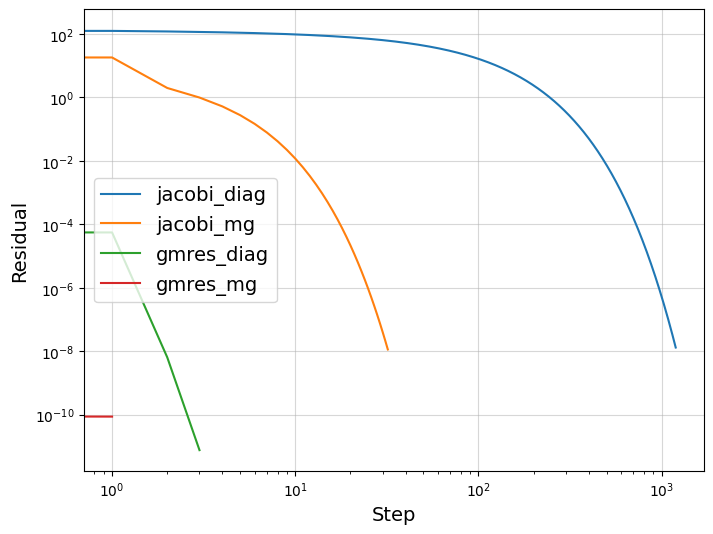

In [8]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

for file in files:
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    plt.plot(np.arange(len(data[:, 1]), dtype=int), data[:, 1], label='_'.join(file.split('/')[1].split('_')[:2]))

plt.legend(fontsize=14)

plt.xlabel('Step', fontsize=14)
plt.ylabel('Residual', fontsize=14)

plt.xscale('log')
plt.yscale('log')

plt.show()

---

## Problem Solution Visualization

In [ ]:
# ============================================================
# Load numerical solution from binary file
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown
import os
import glob

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# Load numerical and exact solutions
folder = 'test_20260317_193554'
folder_path = f'data/{folder}'

# Check for time-dependent solutions (numerical_0.bin, numerical_1.bin, ...)
numerical_files = sorted(glob.glob(f'{folder_path}/numerical_*.bin'),
                         key=lambda x: int(x.split('_')[-1].split('.')[0]))
if len(numerical_files) == 0:
    # Time-independent case: single numerical.bin file
    numerical_files = [f'{folder_path}/numerical.bin']
    if not os.path.exists(numerical_files[0]):
        raise FileNotFoundError(f"Could not find numerical solution file in {folder_path}")

# Load all numerical solutions
numerical_solutions = []
for filename in tqdm(numerical_files):
    data, N = load_solution(filename)
    numerical_solutions.append(data)

# Convert to numpy array: shape will be (num_frames, N, N, N, 2) for time-dependent
# or (1, N, N, N, 2) for time-independent
# Note: index 0 is initial approximation, index 1+ are solutions after time steps
numerical = np.array(numerical_solutions)
num_frames = len(numerical_solutions)

# Ensure numerical always has 5 dimensions (frames, N, N, N, components)
if numerical.ndim == 4:
    numerical = numerical[np.newaxis, ...]  # Add time dimension if missing
    num_frames = 1

# Load exact solution (always single file)
exact_file = f'{folder_path}/exact.bin'
if os.path.exists(exact_file):
    exact_loaded, _ = load_solution(exact_file)
else:
    exact_loaded = None
    print("Warning: exact.bin not found, exact solution will not be displayed")

print(f"Loaded solutions with grid size N = {N}")
print(f"Number of frames: {num_frames} (index 0 = initial approximation, 1-{num_frames-1} = after time steps)")
print(f"Solution shape: {numerical.shape}")
print(f"Components: [psi, phi]")
if exact_loaded is not None:
    print(f"Exact solution shape: {exact_loaded.shape}")

Loaded solutions with grid size N = 64
Number of frames: 1 (index 0 = initial approximation, 1-0 = after time steps)
Solution shape: (1, 64, 64, 64, 2)
Components: [psi, phi]
Exact solution shape: (64, 64, 64, 2)


In [3]:
# ============================================================
# 1D Visualization: exact (loaded) + numerical (scatter) with time slider
# ============================================================
from ipywidgets import interact, FloatSlider, Dropdown, SelectionSlider, IntSlider

# Precompute global min/max for fixed y-axis limits (±10% margin) across all frames
y_limits = {}
for comp in [0, 1]:
    ymin = numerical[:,:,:,:,comp].min()
    ymax = numerical[:,:,:,:,comp].max()
    margin = 0.1 * (ymax - ymin) if ymax != ymin else 0.1
    y_limits[comp] = (ymin - margin, ymax + margin)

# Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
h = 1.0 / N
cell_centered_coords = [h * (0.5 + i) for i in range(N)]

def plot_1d(frame_idx=0, vary_axis=0, fixed_val_1=0.5, fixed_val_2=0.5, component=1):
    """
    1D plot: exact solution (loaded) and numerical as scatter points.

    frame_idx: frame index (0 = initial approximation, 1+ = after time steps)
    vary_axis: 0=x, 1=y, 2=z (coordinate that varies along the line)
    fixed_val_1, fixed_val_2: cell-centered coordinate values for the two fixed coordinates
    component: 0=psi, 1=phi
    """
    axis_names = ['x', 'y', 'z']
    component_names = ['ψ (psi)', 'φ (phi)']

    fixed_axes = [i for i in range(3) if i != vary_axis]

    # Get numerical solution for the selected frame
    # numerical shape is always (num_frames, N, N, N, 2) after preprocessing
    numerical_frame = numerical[frame_idx]

    # Coordinate values for plotting
    t_num = np.array(cell_centered_coords)

    # Find indices corresponding to fixed coordinate values
    idx_1 = cell_centered_coords.index(fixed_val_1)
    idx_2 = cell_centered_coords.index(fixed_val_2)

    # Extract values along the varying axis
    if vary_axis == 0:
        num_vals = numerical_frame[:, idx_1, idx_2, component]
        if exact_loaded is not None:
            exact_vals = exact_loaded[:, idx_1, idx_2, component]
    elif vary_axis == 1:
        num_vals = numerical_frame[idx_1, :, idx_2, component]
        if exact_loaded is not None:
            exact_vals = exact_loaded[idx_1, :, idx_2, component]
    else:
        num_vals = numerical_frame[idx_1, idx_2, :, component]
        if exact_loaded is not None:
            exact_vals = exact_loaded[idx_1, idx_2, :, component]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))

    if exact_loaded is not None:
        ax.plot(t_num, exact_vals, 'b-', lw=2, marker='o', markersize=4, label='Exact')

    ax.scatter(t_num, num_vals, c='red', s=60, zorder=5, label='Numerical', edgecolors='black')

    # Fixed y-axis limits (global min/max ±10%)
    ax.set_ylim(y_limits[component])

    ax.set_xlabel(axis_names[vary_axis], fontsize=14)
    ax.set_ylabel(component_names[component], fontsize=14)

    title = f'Cahn-hilliard: {component_names[component]} along {axis_names[vary_axis]}, '
    title += f'{axis_names[fixed_axes[0]]}={fixed_val_1:.4f}, '
    title += f'{axis_names[fixed_axes[1]]}={fixed_val_2:.4f}'
    if num_frames > 1:
        if frame_idx == 0:
            title += ', Initial approximation'
        else:
            title += f', After iteration {frame_idx}'
    ax.set_title(title, fontsize=12)

    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create frame slider: if only one frame, slider has single value 0
if num_frames > 1:
    frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='Frame:')
else:
    frame_slider = IntSlider(min=0, max=0, value=0, description='Frame:', disabled=True)

interact(
    plot_1d,
    frame_idx=frame_slider,
    vary_axis=Dropdown(options=[('x (fix y,z)', 0), ('y (fix x,z)', 1), ('z (fix x,y)', 2)], value=0, description='Axis:'),
    fixed_val_1=SelectionSlider(options=[(f'{coord:.4f}', coord) for coord in cell_centered_coords], value=cell_centered_coords[N//2], description='Fixed 1:'),
    fixed_val_2=SelectionSlider(options=[(f'{coord:.4f}', coord) for coord in cell_centered_coords], value=cell_centered_coords[N//2], description='Fixed 2:'),
    component=Dropdown(options=[('ψ (psi)', 0), ('φ (phi)', 1)], value=1, description='Field:')
)
plt.show()

interactive(children=(IntSlider(value=0, description='Frame:', disabled=True, max=0), Dropdown(description='Ax…

---

## 2D Heatmap Visualization for Perlin Noise Solution

In [6]:
# folder = 'test_fixed_bc_20260331_152300'  # Change this to your actual folder name
folder = 'small_droplet_test_20260409_153123'

In [ ]:
# ============================================================
# 2D Heatmap Visualization for Perlin Noise Solution
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown, Play, jslink
import os
import glob

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# Update this folder name to match your Perlin noise run
folder_path = f'data/{folder}'

# Check for time-dependent solutions (numerical_0.bin, numerical_1.bin, ...)
numerical_files = sorted(glob.glob(f'{folder_path}/numerical_*.bin'),
                         key=lambda x: int(x.split('_')[-1].split('.')[0]))
if len(numerical_files) == 0:
    # Time-independent case: single numerical.bin file
    numerical_files = [f'{folder_path}/numerical.bin']
    if not os.path.exists(numerical_files[0]):
        raise FileNotFoundError(f"Could not find numerical solution file in {folder_path}")

# Load all numerical solutions
numerical_solutions = []
for filename in tqdm(numerical_files):
    data, N = load_solution(filename)
    numerical_solutions.append(data)

# Convert to numpy array: shape will be (num_frames, N, N, N, 2) for time-dependent
# or (1, N, N, N, 2) for time-independent
# Note: index 0 is initial approximation, index 1+ are solutions after time steps
numerical = np.array(numerical_solutions)
num_frames = len(numerical_solutions)

# Ensure numerical always has 5 dimensions (frames, N, N, N, components)
if numerical.ndim == 4:
    numerical = numerical[np.newaxis, ...]  # Add time dimension if missing
    num_frames = 1

print(f"Loaded solutions with grid size N = {N}")
print(f"Number of frames: {num_frames} (index 0 = initial approximation, 1-{num_frames-1} = after time steps)")
print(f"Solution shape: {numerical.shape}")
print(f"Components: [psi, phi]")

# Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
h = 1.0 / N
cell_centered_coords = np.array([h * (0.5 + i) for i in range(N)])

# Precompute global min/max for consistent colorbar scaling across all frames
vmin_global = {}
vmax_global = {}
for comp in [0, 1]:
    vmin_global[comp] = numerical[:,:,:,:,comp].min()
    vmax_global[comp] = numerical[:,:,:,:,comp].max()

def plot_2d_heatmap(frame_idx=0, slice_axis=0, layer_idx=16, component=1):
    """
    2D heatmap visualization of solution slice.

    frame_idx: frame index (0 = initial approximation, 1+ = after time steps)
    slice_axis: 0=x, 1=y, 2=z (axis perpendicular to the slice plane)
    layer_idx: index of the layer along slice_axis (0 to N-1)
    component: 0=psi, 1=phi
    """
    axis_names = ['x', 'y', 'z']
    component_names = ['ψ (psi)', 'φ (phi)']

    # Get numerical solution for the selected frame
    numerical_frame = numerical[frame_idx]

    # Extract 2D slice based on slice_axis and layer_idx
    if slice_axis == 0:  # Slice along x-axis: show y-z plane
        slice_data = numerical_frame[layer_idx, :, :, component]
        x_coords = cell_centered_coords  # y coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'y'
        ylabel = 'z'
        title_axis = f'x = {cell_centered_coords[layer_idx]:.4f}'
    elif slice_axis == 1:  # Slice along y-axis: show x-z plane
        slice_data = numerical_frame[:, layer_idx, :, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'x'
        ylabel = 'z'
        title_axis = f'y = {cell_centered_coords[layer_idx]:.4f}'
    else:  # slice_axis == 2, Slice along z-axis: show x-y plane
        slice_data = numerical_frame[:, :, layer_idx, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # y coordinates
        xlabel = 'x'
        ylabel = 'y'
        title_axis = f'z = {cell_centered_coords[layer_idx]:.4f}'

    # Plot with imshow (no interpolation, pixelated)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(
        slice_data.T,                       # Transpose so that axes match: y first, then x
        origin='lower',
        aspect='equal',
        cmap='viridis',
        extent=[x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]],
        vmin=vmin_global[component],
        vmax=vmax_global[component],
        interpolation='none'
    )

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(component_names[component], fontsize=14)

    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # Title
    title = f'Cahn-Hilliard: {component_names[component]} slice at {title_axis}'
    if num_frames > 1:
        if frame_idx == 0:
            title += ', Initial approximation'
        else:
            title += f', After iteration {frame_idx}'
    ax.set_title(title, fontsize=14)

    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# Create frame slider: if only one frame, slider has single value 0
if num_frames > 1:
    frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='Frame:')
else:
    frame_slider = IntSlider(min=0, max=0, value=0, description='Frame:', disabled=True)

# Create layer slider (stays fully manual)
layer_slider = IntSlider(min=0, max=N-1, value=N//2, description='Layer:')

# Optional auto-iteration over frames only.
# Layer remains under manual control.
from IPython.display import display

if num_frames > 1:
    frame_play = Play(
        value=int(frame_slider.value),
        min=0,
        max=num_frames-1,
        step=1,
        interval=150,  # ms between frames (reduce if you want faster)
        description='Auto Frame',
    )

    a_sync = {'on': False}

    def _play_to_frame(change):
        if a_sync['on']:
            return
        a_sync['on'] = True
        frame_slider.value = int(change['new'])
        a_sync['on'] = False

    def _frame_to_play(change):
        if a_sync['on']:
            return
        a_sync['on'] = True
        frame_play.value = int(change['new'])
        a_sync['on'] = False

    frame_play.observe(_play_to_frame, names='value')
    frame_slider.observe(_frame_to_play, names='value')

    display(frame_play)

interact(
    plot_2d_heatmap,
    frame_idx=frame_slider,
    slice_axis=Dropdown(
        options=[('x (show y-z plane)', 0), ('y (show x-z plane)', 1), ('z (show x-y plane)', 2)],
        value=2,
        description='Slice axis:'
    ),
    layer_idx=layer_slider,
    component=Dropdown(
        options=[('ψ (psi)', 0), ('φ (phi)', 1)],
        value=1,
        description='Field:'
    )
)
plt.show()

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [00:39<00:00,  3.80it/s]


Loaded solutions with grid size N = 128
Number of frames: 150 (index 0 = initial approximation, 1-149 = after time steps)
Solution shape: (150, 128, 128, 128, 2)
Components: [psi, phi]


Play(value=0, description='Auto Frame', interval=150, max=149)

interactive(children=(IntSlider(value=0, description='Frame:', max=149), Dropdown(description='Slice axis:', i…

In [25]:
# ============================================================
# 2D Contour Plot Visualization for Perlin Noise Solution
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown
import os
import glob

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# Update this folder name to match your Perlin noise run
folder_path = f'data/{folder}'

# Check for time-dependent solutions (numerical_0.bin, numerical_1.bin, ...)
numerical_files = sorted(glob.glob(f'{folder_path}/numerical_*.bin'),
                         key=lambda x: int(x.split('_')[-1].split('.')[0]))
if len(numerical_files) == 0:
    # Time-independent case: single numerical.bin file
    numerical_files = [f'{folder_path}/numerical.bin']
    if not os.path.exists(numerical_files[0]):
        raise FileNotFoundError(f"Could not find numerical solution file in {folder_path}")

# Load all numerical solutions
numerical_solutions = []
for filename in tqdm(numerical_files):
    data, N = load_solution(filename)
    numerical_solutions.append(data)

# Convert to numpy array: shape will be (num_frames, N, N, N, 2) for time-dependent
# or (1, N, N, N, 2) for time-independent
# Note: index 0 is initial approximation, index 1+ are solutions after time steps
numerical = np.array(numerical_solutions)
num_frames = len(numerical_solutions)

# Ensure numerical always has 5 dimensions (frames, N, N, N, components)
if numerical.ndim == 4:
    numerical = numerical[np.newaxis, ...]  # Add time dimension if missing
    num_frames = 1

print(f"Loaded solutions with grid size N = {N}")
print(f"Number of frames: {num_frames} (index 0 = initial approximation, 1-{num_frames-1} = after time steps)")
print(f"Solution shape: {numerical.shape}")
print(f"Components: [psi, phi]")

# Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
h = 1.0 / N
cell_centered_coords = np.array([h * (0.5 + i) for i in range(N)])

# Precompute global min/max for consistent colorbar scaling across all frames
vmin_global = {}
vmax_global = {}
for comp in [0, 1]:
    vmin_global[comp] = numerical[:,:,:,:,comp].min()
    vmax_global[comp] = numerical[:,:,:,:,comp].max()

def plot_2d_contour(frame_idx=0, slice_axis=0, layer_idx=16, component=1, num_levels=6):
    """
    2D contour plot visualization of solution slice.

    frame_idx: frame index (0 = initial approximation, 1+ = after time steps)
    slice_axis: 0=x, 1=y, 2=z (axis perpendicular to the slice plane)
    layer_idx: index of the layer along slice_axis (0 to N-1)
    component: 0=psi, 1=phi
    num_levels: how many contour levels to plot
    """
    axis_names = ['x', 'y', 'z']
    component_names = ['ψ (psi)', 'φ (phi)']

    # Get numerical solution for the selected frame
    numerical_frame = numerical[frame_idx]

    # Extract 2D slice based on slice_axis and layer_idx
    if slice_axis == 0:  # Slice along x-axis: show y-z plane
        slice_data = numerical_frame[layer_idx, :, :, component]
        x_coords = cell_centered_coords  # y coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'y'
        ylabel = 'z'
        title_axis = f'x = {cell_centered_coords[layer_idx]:.4f}'
    elif slice_axis == 1:  # Slice along y-axis: show x-z plane
        slice_data = numerical_frame[:, layer_idx, :, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'x'
        ylabel = 'z'
        title_axis = f'y = {cell_centered_coords[layer_idx]:.4f}'
    else:  # slice_axis == 2, Slice along z-axis: show x-y plane
        slice_data = numerical_frame[:, :, layer_idx, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # y coordinates
        xlabel = 'x'
        ylabel = 'y'
        title_axis = f'z = {cell_centered_coords[layer_idx]:.4f}'

    X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

    # Plot with contourf and contour for filled levels and lines
    fig, ax = plt.subplots(figsize=(10, 8))
    # Filled contours
    levels = np.linspace(vmin_global[component], vmax_global[component], num_levels)
    cf = ax.contourf(
        X.T, Y.T, slice_data.T, levels=levels, cmap='viridis', extend='both'
    )
    # Contour lines
    c = ax.contour(
        X.T, Y.T, slice_data.T, levels=levels, colors='k', linewidths=0.5, linestyles='solid'
    )

    # Colorbar
    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label(component_names[component], fontsize=14)

    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # Title
    title = f'Cahn-Hilliard: {component_names[component]} slice at {title_axis}'
    if num_frames > 1:
        if frame_idx == 0:
            title += ', Initial approximation'
        else:
            title += f', After iteration {frame_idx}'
    ax.set_title(title, fontsize=14)

    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# Create frame slider: if only one frame, slider has single value 0
if num_frames > 1:
    frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='Frame:')
else:
    frame_slider = IntSlider(min=0, max=0, value=0, description='Frame:', disabled=True)

# Create layer slider
layer_slider = IntSlider(min=0, max=N-1, value=N//2, description='Layer:')

# Add number of contour levels slider
num_levels_slider = IntSlider(min=2, max=10, value=5, step=1, description='Levels:')

interact(
    plot_2d_contour,
    frame_idx=frame_slider,
    slice_axis=Dropdown(
        options=[('x (show y-z plane)', 0), ('y (show x-z plane)', 1), ('z (show x-y plane)', 2)],
        value=2,
        description='Slice axis:'
    ),
    layer_idx=layer_slider,
    component=Dropdown(
        options=[('ψ (psi)', 0), ('φ (phi)', 1)],
        value=1,
        description='Field:'
    ),
    num_levels=num_levels_slider
)
plt.show()

100%|██████████| 72/72 [00:00<00:00, 111.55it/s]


Loaded solutions with grid size N = 128
Number of frames: 72 (index 0 = initial approximation, 1-71 = after time steps)
Solution shape: (72, 128, 128, 128, 2)
Components: [psi, phi]


interactive(children=(IntSlider(value=0, description='Frame:', max=71), Dropdown(description='Slice axis:', in…

---

## 3D Isosurface Visualization of phi = 0

In [11]:
folder = 'circle_test_20260318_171341'  # Change this to your actual folder name

In [ ]:
# ============================================================
# 3D Isosurface Visualization of phi = 0
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from ipywidgets import interact, IntSlider, FloatSlider
import os
import glob
from skimage import measure

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# Update this folder name to match your calculation folder
folder_path = f'data/{folder}'

# Check for time-dependent solutions (numerical_0.bin, numerical_1.bin, ...)
numerical_files = sorted(glob.glob(f'{folder_path}/numerical_*.bin'),
                         key=lambda x: int(x.split('_')[-1].split('.')[0]))
if len(numerical_files) == 0:
    # Time-independent case: single numerical.bin file
    numerical_files = [f'{folder_path}/numerical.bin']
    if not os.path.exists(numerical_files[0]):
        raise FileNotFoundError(f"Could not find numerical solution file in {folder_path}")

# Load all numerical solutions
numerical_solutions = []
for filename in numerical_files:
    data, N = load_solution(filename)
    numerical_solutions.append(data)

# Convert to numpy array: shape will be (num_frames, N, N, N, 2)
numerical = np.array(numerical_solutions)
num_frames = len(numerical_solutions)

# Ensure numerical always has 5 dimensions (frames, N, N, N, components)
if numerical.ndim == 4:
    numerical = numerical[np.newaxis, ...]
    num_frames = 1

print(f"Loaded solutions with grid size N = {N}")
print(f"Number of frames: {num_frames} (index 0 = initial approximation, 1-{num_frames-1} = after time steps)")
print(f"Solution shape: {numerical.shape}")

# Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
h = 1.0 / N
cell_centered_coords = np.array([h * (0.5 + i) for i in range(N)])

# Create coordinate grids for 3D space
x_coords = cell_centered_coords
y_coords = cell_centered_coords
z_coords = cell_centered_coords

def plot_3d_isosurface(frame_idx=0, azimuth=45, elevation=30):
    """
    3D isosurface visualization of phi = 0.

    frame_idx: frame index (0 = initial approximation, 1+ = after time steps)
    azimuth: azimuth angle for camera position (degrees)
    elevation: elevation angle for camera position (degrees)
    """
    # Get phi component (component 1) for the selected frame
    phi_data = numerical[frame_idx, :, :, :, 1]  # Shape: (N, N, N)

    # Extract isosurface at phi = 0 using marching cubes
    try:
        verts, faces, normals, values = measure.marching_cubes(phi_data, level=0.0, spacing=(h, h, h))
    except ValueError as e:
        print(f"Warning: Could not extract isosurface: {e}")
        print("This might happen if there are no points where phi = 0")
        return

    # Create figure and 3D axis
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Create mesh from the isosurface
    mesh = Poly3DCollection(verts[faces], alpha=0.5, facecolor='cyan', edgecolor='none')
    ax.add_collection3d(mesh)

    # Set axis limits to show the full cube [0, 1]^3
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)

    # Set labels
    ax.set_xlabel('x', fontsize=14)
    ax.set_ylabel('y', fontsize=14)
    ax.set_zlabel('z', fontsize=14)

    # Set camera position
    ax.view_init(elev=elevation, azim=azimuth)

    # Title
    title = 'Cahn-Hilliard: φ = 0 Isosurface'
    if num_frames > 1:
        if frame_idx == 0:
            title += ', Initial approximation'
        else:
            title += f', After iteration {frame_idx}'
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Create frame slider
if num_frames > 1:
    frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='Frame:')
else:
    frame_slider = IntSlider(min=0, max=0, value=0, description='Frame:', disabled=True)

# Create camera position sliders
azimuth_slider = FloatSlider(min=0, max=360, value=45, step=5, description='Azimuth:')
elevation_slider = FloatSlider(min=-90, max=90, value=30, step=5, description='Elevation:')

interact(
    plot_3d_isosurface,
    frame_idx=frame_slider,
    azimuth=azimuth_slider,
    elevation=elevation_slider
)
plt.show()

Loaded solutions with grid size N = 128
Number of frames: 72 (index 0 = initial approximation, 1-71 = after time steps)
Solution shape: (72, 128, 128, 128, 2)


interactive(children=(IntSlider(value=0, description='Frame:', max=71), FloatSlider(value=45.0, description='A…

---

In [8]:
folder = 'small_droplet_test_20260409_145848'

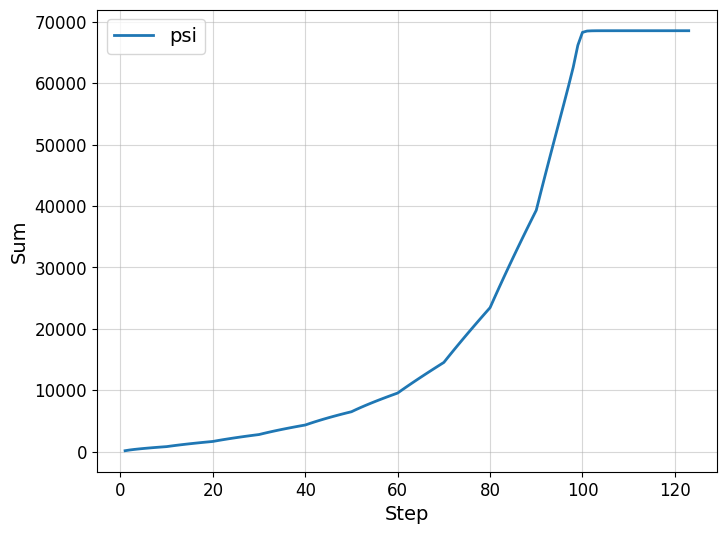

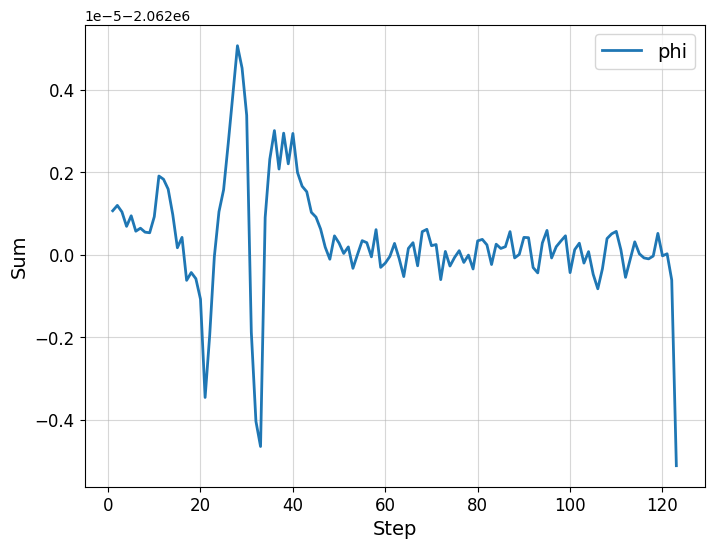

In [9]:
data = np.loadtxt(f'data/{folder}/component_sums.dat', delimiter=' ', skiprows=1)

for i in range(1,3):
    plt.figure(figsize=(8, 6))
    plt.grid(alpha=0.5)

    if i == 1:
        plt.plot(data[:, 0], data[:, 1], lw=2, label='psi')
    else:
        plt.plot(data[:, 0], data[:, 2], lw=2, label='phi')

    plt.xlabel('Step', fontsize=14)
    plt.ylabel('Sum', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=14)
    plt.show()

/tmp/ipykernel_109565/1621784218.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


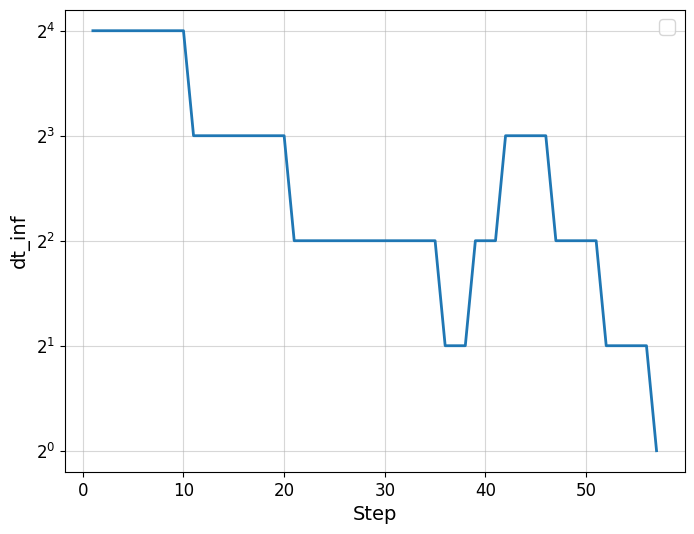

In [62]:
data = np.loadtxt(f'data/{folder}/dt_history.dat', delimiter=' ', skiprows=1)

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

plt.plot(data[:, 0], data[:, 1], lw=2)

plt.xlabel('Step', fontsize=14)
plt.ylabel('dt_inf', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14)

plt.yscale('log', base=2)

plt.show()

---

In [10]:
path = 'data/gamma_MyC4_test'

# gammas = ['13e-4', '12e-4', '11e-4', '10e-4', '9e-4', '8e-4', '7e-4', '6e-4']
# gammas = ['13e-4', '11e-4', '9e-4', '7e-4', '5e-4', '3e-4', '1e-4']
gammas = ['1e-1', '1e-2', '1e-3', '1e-4']

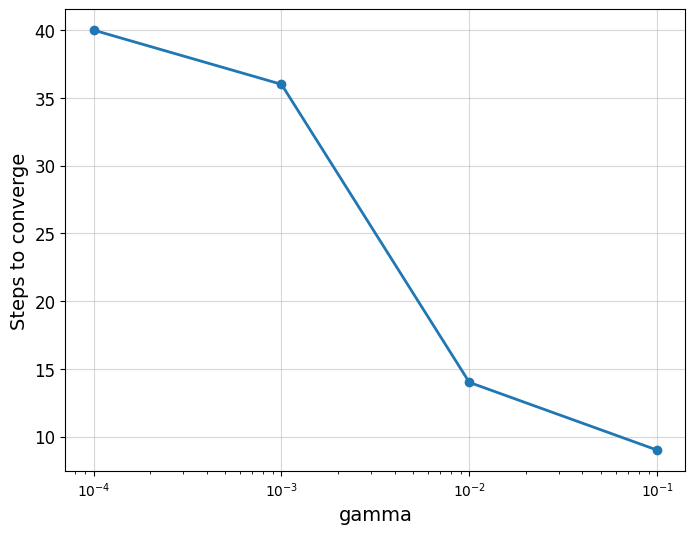

In [11]:
steps = []

for gamma in gammas:
    for folder in os.listdir(path):
        if folder.startswith(f'gamma_{gamma}'):
            data = np.loadtxt(f'{path}/{folder}/time_converge_history.dat', delimiter=' ', skiprows=1)
            steps.append(data[-1, 0])

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

plt.plot([float(gamma) for gamma in gammas], steps, '-o', lw=2)

plt.xlabel('gamma', fontsize=14)
plt.ylabel('Steps to converge', fontsize=14)

# plt.xticks([float(gamma) for gamma in gammas], gammas,fontsize=12)
plt.yticks(fontsize=12)
plt.xscale('log', base=10)

plt.show()


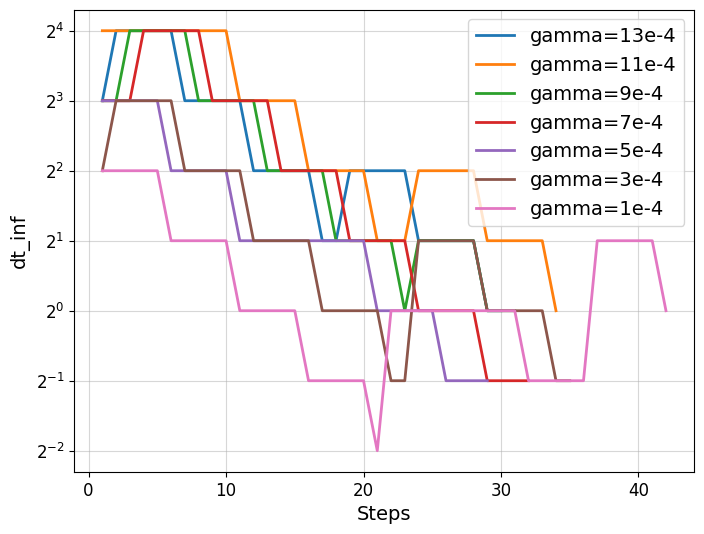

In [18]:
steps = []

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

for gamma in gammas:
    for folder in os.listdir(path):
        if folder.startswith(f'gamma_{gamma}'):
            data = np.loadtxt(f'{path}/{folder}/dt_history.dat', delimiter=' ', skiprows=1)
            plt.plot(data[:, 0], data[:, 1], lw=2, label=f'gamma={gamma}')

plt.xlabel('Steps', fontsize=14)
plt.ylabel('dt_inf', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# plt.xscale('log', base=10)
plt.yscale('log', base=2)

plt.legend(fontsize=14)

plt.show()


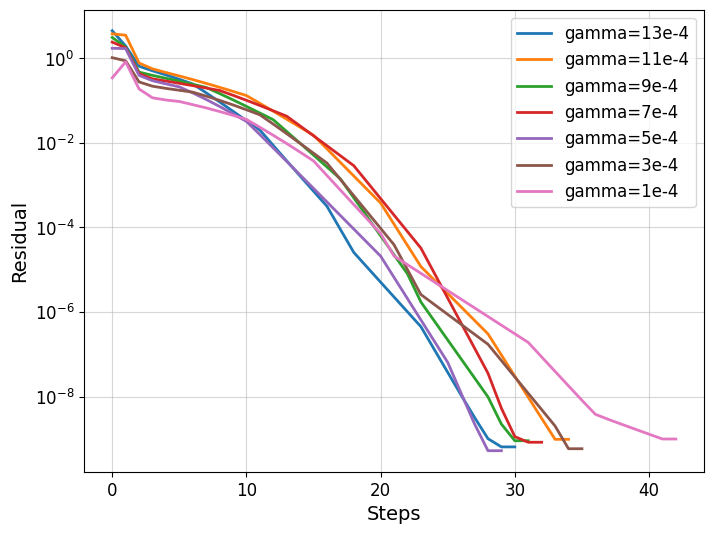

In [45]:
steps = []

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

for gamma in gammas:
    for folder in os.listdir(path):
        if folder.startswith(f'gamma_{gamma}'):
            data = np.loadtxt(f'{path}/{folder}/time_converge_history.dat', delimiter=' ', skiprows=1)
            plt.plot(data[:, 0], data[:, 1], lw=2, label=f'gamma={gamma}')

plt.xlabel('Steps', fontsize=14)
plt.ylabel('Residual', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks([1e0, 1e-3, 1e-6, 1e-9], ['1e0', '1e-3', '1e-6', '1e-9'], fontsize=12)

# plt.xscale('log', base=10)
plt.yscale('log', base=10)

plt.legend(fontsize=12)

plt.show()


---

In [4]:
os.listdir(path)

FileNotFoundError: [Errno 2] No such file or directory: 'fixed_bc'

In [33]:
# path = "data/fixes_test"
# path = "data/new_bc_gamma"

# paths = os.listdir(path)
# paths = [
#     # 'baseline_20260323_174902',
#     # 'rest_prol_pbc_20260323_180355',
#     # 'rest_non_lin_flag_20260323_181248',
#     # 'gamma_oleg_20260323_182207',
#     'C_2_20260324_164525',
#     'C_4_20260324_165239',
#     'C_8_20260324_165915',
#     'C_9_20260324_225609',
#     'C_12_20260324_171434',
#     'C_16_20260324_170623'
# ]

# paths = [
#     "myC4_20260326_112718",
#     "C2_20260326_123524",
#     "C4_20260326_122034",
#     "C6_20260326_125227",
#     "C8_20260326_114801",
# ]

# ----------------------------------------

path = "data/fixed_bc_cos_theta_test"

paths = [
    "cos_theta_-1.0_20260331_155146",
    "cos_theta_-0.8660254038_20260331_155146",
    "cos_theta_-0.7071067812_20260331_155146",
    "cos_theta_-0.5_20260331_155146",
    "cos_theta_0_20260331_155146",
    "cos_theta_0.5_20260331_155146",
    "cos_theta_0.7071067812_20260331_155146",
    "cos_theta_0.8660254038_20260331_155146",
    "cos_theta_1.0_20260331_155146"
]

# ----------------------------------------

# path = "data/fixed_bc"

# paths = [
#     "NoC_20260331_144910",
#     "MyC4_20260331_150110",
#     "C4_20260331_150716",
#     "C8_20260331_151439"
# ]

0.0004393681670574392
8.632565164516229e-10
8.644481828169841e-10
4.559836547013593e-10
8.021395828971552e-10
7.979744188294361e-10
7.018936022766701e-10
2.010403913316082e-10
7.11576796235533e-10


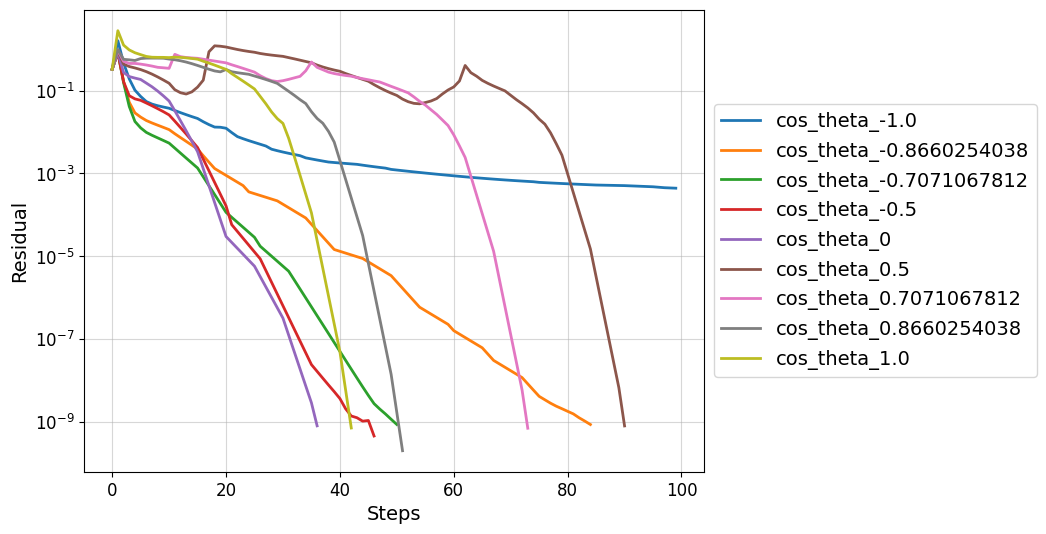

In [49]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

begin = 0

# for folder in os.listdir(path):
for folder in paths:
    name = "_".join(folder.split('_')[:-2])

    data = np.loadtxt(f'{path}/{folder}/time_converge_history.dat', delimiter=' ', skiprows=1)
    data = data[:-1, :] # remove last row
    print(data[-1, 1])

    plt.plot(data[begin:, 0], data[begin:, 1], lw=2, label=name)

plt.xlabel('Steps', fontsize=14)
plt.ylabel('Residual', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))  # Легенда справа

plt.yscale('log', base=10)

# plt.ylim(1e-10, 1e0)

# plt.tight_layout(rect=[0, 0, 0.8, 1])  # Оставляем место справа для легенды
plt.show()


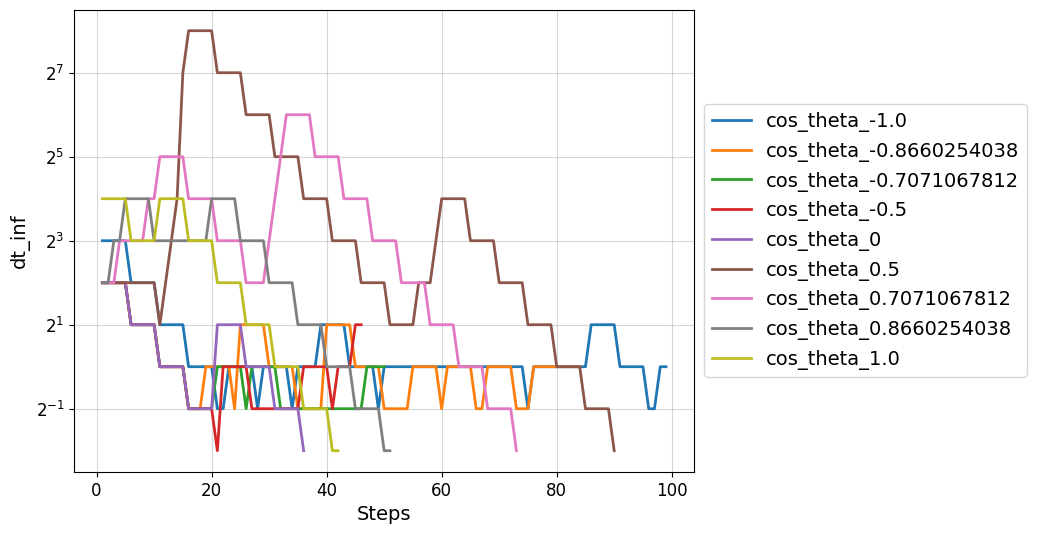

In [50]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

# for folder in os.listdir(path):
for folder in paths:
    name = "_".join(folder.split('_')[:-2])

    data = np.loadtxt(f'{path}/{folder}/dt_history.dat', delimiter=' ', skiprows=1)
    data = data[:-1, :] # remove last row

    plt.plot(data[:, 0], data[:, 1], lw=2, label=name)

plt.xlabel('Steps', fontsize=14)
plt.ylabel('dt_inf', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# plt.legend(fontsize=14)
plt.legend(fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))  # Легенда справа

plt.yscale('log', base=2)

plt.show()


/tmp/ipykernel_116132/993068462.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


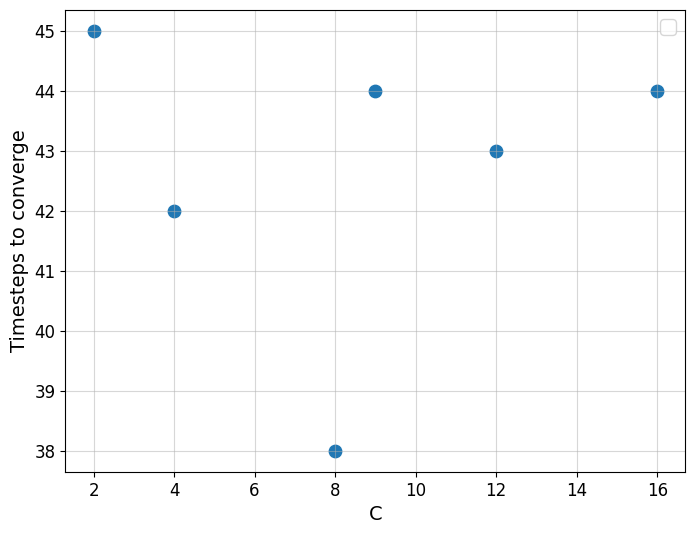

In [11]:
path = "data/fixes_test"

# paths = os.listdir(path)
paths = [
    'C_2_20260324_164525',
    'C_4_20260324_165239',
    'C_8_20260324_165915',
    'C_9_20260324_225609',
    'C_12_20260324_171434',
    'C_16_20260324_170623'
]

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

Cs = []
Steps = []
# for folder in os.listdir(path):
for folder in paths:
    name = "_".join(folder.split('_')[:-2])
    Cs.append(int(folder.split('_')[1]))

    data = np.loadtxt(f'{path}/{folder}/time_converge_history.dat', delimiter=' ', skiprows=1)
    Steps.append(data[-1, 0])

plt.scatter(Cs, Steps, s=80)


plt.xlabel('C', fontsize=14)
plt.ylabel('Timesteps to converge', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14)


plt.show()


In [ ]:
plt.figure(figsize=(8, 6))
# plt.grid(alpha=0.5)

# for folder in os.listdir(path):
names = []
lin_solver_steps = []
Cs = []
for folder in paths:
    names.append("_".join(folder.split('_')[:-2]))
    Cs.append(int(folder.split('_')[1]))
    lin_solver_steps.append([])

    for step_folder in os.listdir(f'{path}/{folder}'):
        if step_folder.startswith('step_'):
            max_attempt = 0
            for attempt_folder in os.listdir(f'{path}/{folder}/{step_folder}'):
                if attempt_folder.startswith('attempt_'):
                    max_attempt = max(max_attempt, int(attempt_folder.split('_')[-1]))

            if max_attempt == 0:
                raise ValueError(f'No attempt found for {folder}/{step_folder}')

            for conv_file in os.listdir(f'{path}/{folder}/{step_folder}/attempt_{max_attempt}'):
                if conv_file.startswith('convergence_history_'):
                    data = np.loadtxt(f'{path}/{folder}/{step_folder}/attempt_{max_attempt}/{conv_file}', delimiter=' ', skiprows=1)
                    lin_solver_steps[-1].append(data[-1, 0])


# for data, name, C in zip(lin_solver_steps, names, Cs):
    # plt.hist(data, bins=10, alpha=0.5, label=name)

plt.bar(range(len(Cs)), [sum(data) for data in lin_solver_steps], label=names, width=0.6)

# plt.xlabel('Steps', fontsize=14)
plt.ylabel('Total Linear Solver Steps', fontsize=14)

plt.xticks(range(len(Cs)), [f'C={C}' for C in Cs], fontsize=14)
plt.yticks(fontsize=12)

plt.ylim(1e4, 1.5e4)
plt.yscale('log', base=10)

plt.show()


---

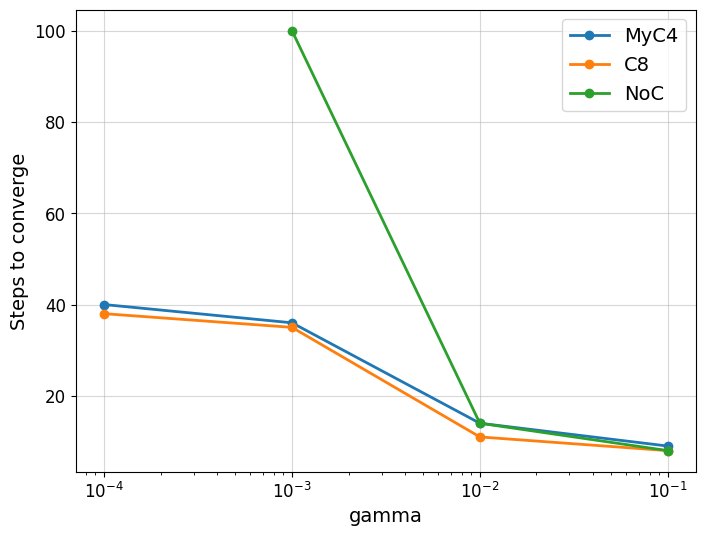

In [2]:
paths = ['data/gamma_MyC4_test', 'data/gamma_C8_test', 'data/gamma_NoC_test']

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

for path in paths:
    gammas = []
    steps = []

    for gamma_folder in os.listdir(path):
        gamma = gamma_folder.split('_')[1]

        data = np.loadtxt(f'{path}/{gamma_folder}/time_converge_history.dat', delimiter=' ', skiprows=1).reshape(-1, 2)
        if data[-1, 0] == 0:
            continue

        gammas.append(float(gamma))
        steps.append(data[-1, 0])

    gammas = np.array(gammas)
    steps = np.array(steps)
    order = np.argsort(gammas)

    plt.plot(gammas[order], steps[order], '-o', lw=2, label=path.split('_')[1])

plt.xlabel('gamma', fontsize=14)
plt.ylabel('Steps to converge', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14)

plt.xscale('log', base=10)

plt.show()


---

C0:  1.0140360796179568
C_ghost:  1.0248936526763208
Nonlinear BC:  1.199040866595169e-14


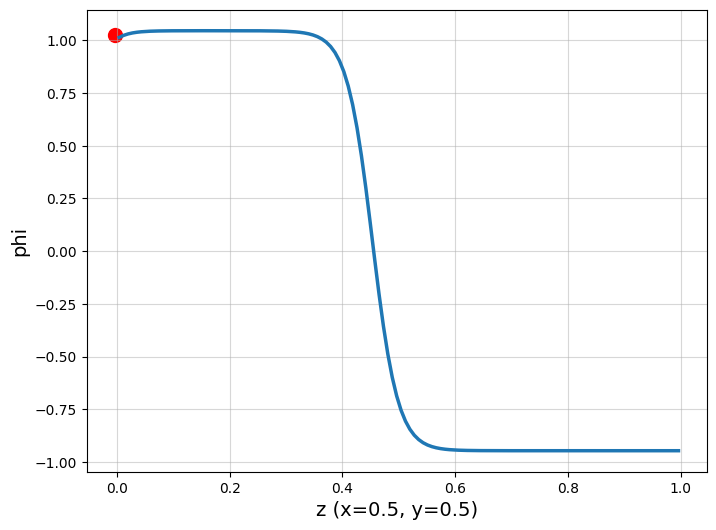

In [ ]:
path = 'data/test_nonlin_20260326_111351'

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

def get_ghost_cell(C0, h, cos_theta, gamma):
    # A = h * cos_theta / np.sqrt(2 * gamma);
    # D = 1 + A * C0 + A * A;
    A = h * cos_theta / np.sqrt(2 * gamma);
    D = A * A + 2 * A * C0 + 1

    return (
        ( +2 * np.sqrt( D ) - A * C0 - 2 ) / A,
        ( -2 * np.sqrt( D ) - A * C0 - 2 ) / A
    )

# def get_ghost_cell(C0, h, cos_theta, gamma):
#     # A = h * cos_theta / np.sqrt(2 * gamma);
#     # D = 1 + A * C0 + A * A;
#     A = 3/16 * h * cos_theta / np.sqrt(2 * gamma);
#     D = A * A + 2 * A * C0 + 1

#     return (
#         ( +2 * np.sqrt( D ) - A * C0 - 2 ) / A,
#         ( -2 * np.sqrt( D ) - A * C0 - 2 ) / A
#     )

def nonlinear_bc(C_ghost, C0, h, cos_theta, gamma):
    return (C0 - C_ghost) / h - cos_theta / np.sqrt(2 * gamma) * ((C0 + C_ghost)**2 / 4 - 1)

data, N = load_solution(f'{path}/numerical_57.bin')



h = 1 / N
cos_theta = -0.5
gamma = 1e-4

x = (0.5 + np.arange(N)) * h

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

plt.plot(x, data[64, 64, :, 1], lw=2.5)
C_ghost, _ = get_ghost_cell(data[64, 64, 0, 1], h, -0.5, 1e-4)
plt.scatter(-h/2, C_ghost, color='red', s=100)
# plt.scatter(-h/2, C2, color='blue', s=100)

print("C0: ", data[64, 64, 0, 1])
print("C_ghost: ", C_ghost)
print("Nonlinear BC: ", nonlinear_bc(C_ghost, data[64, 64, 0, 1], h, -0.5, 1e-4))

plt.xlabel('z (x=0.5, y=0.5)', fontsize=14)
plt.ylabel('phi', fontsize=14)

plt.show()

In [4]:
print("Max: ", np.max(data[64, 64, :, 1]))
print("Min: ", np.min(data[64, 64, :, 1]))
print("Delta: ", np.max(data[64, 64, :, 1]) - np.min(data[64, 64, :, 1]))
print("Mean: ", (np.max(data[64, 64, :, 1]) + np.min(data[64, 64, :, 1])) / 2)


Max:  1.0458833783407786
Min:  -0.9466611759129179
Delta:  1.9925445542536964
Mean:  0.049611101213930364


In [26]:
C = np.linspace(-1, 1, 100)

cos_theta = -0.5
gamma = 1e-4

def plot_ghost_cell(N=32):
    h = 1 / N

    plt.figure(figsize=(8, 6))
    plt.grid(alpha=0.5)

    plt.plot(C, get_ghost_cell(C, h, cos_theta, gamma)[0], lw=2.5, label='+')
    plt.plot(C, get_ghost_cell(C, h, cos_theta, gamma)[1], lw=2.5, label='-')

    plt.hlines(-1, -1, 1, color='black', linestyle='--', lw=2)
    plt.hlines(1, -1, 1, color='black', linestyle='--', lw=2)

    plt.xlabel('C_internal', fontsize=14)
    plt.ylabel('C_ghost', fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.ylim(-1.5, 2)
    plt.title(f'N = {N}, h = {h:.5f}', fontsize=13)

    plt.legend(fontsize=14)
    plt.show()

interact(plot_ghost_cell, N=IntSlider(min=1, max=64, step=1, value=32, description='N'));

interactive(children=(IntSlider(value=32, description='N', max=64, min=1), Output()), _dom_classes=('widget-in…